# Import Required Libraries

In [1]:
import sys

sys.path.insert(0, "../../src")
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython import display

import bss.PredictiveDecorrBSS_GeneralPolytope as _polymod
from bss.PredictiveDecorrBSS_GeneralPolytope import PredictiveDecorrGeneralPolytope
from bss.bss_utils import addWGN
from python_utils.visualization_utils import display_matrix, subplot_1D_signals
from python_utils.python_utils import Timer

import warnings

warnings.filterwarnings("ignore")
# _polymod.tqdm = lambda it, **k: it  # silence per-epoch progress bars for a clean notebook

notebook_name = "General_Polytope"


# --- Practical-polytope helpers (dependency-free replacements for polytope_utils) ---
def polytope_inequalities(dim, signed_dims, nn_dims, sparse_dims_list):
    """Inequality description A s <= b of the practical polytope
       { s : s_i in [-1,1] (signed), s_i in [0,1] (nonneg), ||s_{J_k}||_1 <= 1 }."""
    A, b = [], []
    for j in signed_dims:
        r = [0] * dim; r[j] = 1;  A.append(r); b.append(1)
        r = [0] * dim; r[j] = -1; A.append(r); b.append(1)
    for j in nn_dims:
        r = [0] * dim; r[j] = 1;  A.append(r); b.append(1)
        r = [0] * dim; r[j] = -1; A.append(r); b.append(0)
    for grp in sparse_dims_list:
        for combo in itertools.product(*[[1, -1] for _ in grp]):
            r = np.zeros(dim); r[np.array(grp)] = combo; A.append(list(r)); b.append(1)
    return np.array(A, dtype=float), np.array(b, dtype=float)


def generate_uniform_points_in_polytope(A, b, nn_dims, N):
    """Uniform samples inside { s : A s <= b } via rejection sampling from the bounding box."""
    dim = A.shape[1]
    lo = np.full(dim, -1.0); hi = np.ones(dim); lo[nn_dims] = 0.0
    collected, total = [], 0
    while total < N:
        M = np.random.uniform(lo, hi, size=(600000, dim))
        keep = np.all(M @ A.T <= b + 1e-9, axis=1)
        collected.append(M[keep]); total += M[keep].shape[0]
    return np.vstack(collected)[:N].T

In [2]:
# Fixed seed with a well-conditioned mixing matrix (reproducible good SNR per source)
seed_ = 200
print(seed_)
np.random.seed(seed_)

200


# Source Generation and Mixing Scenario

In [3]:
dim = 3
N = 500000
NumberofSources = dim
NumberofMixtures = 6

signed_dims = np.array([0, 1])
nn_dims = np.array([2])
sparse_dims_list = [np.array([0, 1]), np.array([1, 2])]
A_ineq, b_ineq = polytope_inequalities(dim, signed_dims, nn_dims, sparse_dims_list)
S = generate_uniform_points_in_polytope(A_ineq, b_ineq, nn_dims, N)

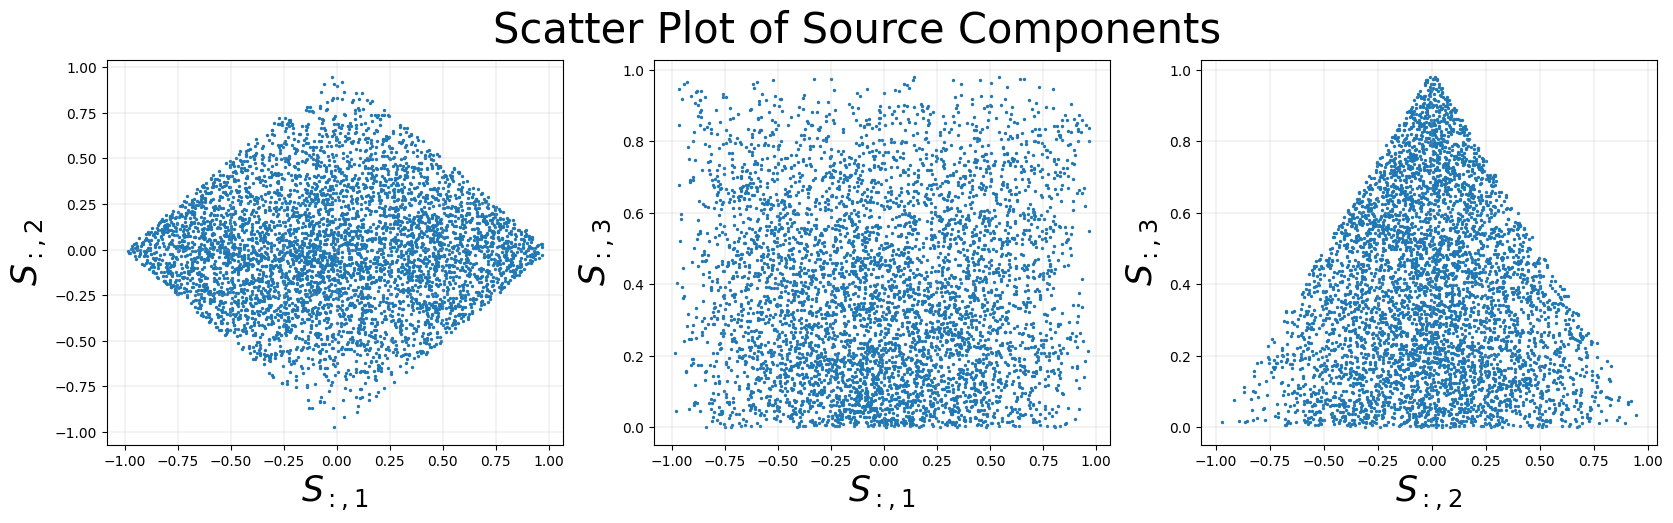

In [4]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.scatter(S[0, :5000], S[1, :5000], s=2)
plt.xlabel("$S_{:,1}$", fontsize=25)
plt.ylabel("$S_{:,2}$", fontsize=25)
plt.grid(linewidth=0.2)
plt.subplot(1, 3, 2)
plt.scatter(S[0, :5000], S[2, :5000], s=2)
plt.xlabel("$S_{:,1}$", fontsize=25)
plt.ylabel("$S_{:,3}$", fontsize=25)
plt.grid(linewidth=0.2)
plt.subplot(1, 3, 3)
plt.scatter(S[1, :5000], S[2, :5000], s=2)
plt.xlabel("$S_{:,2}$", fontsize=25)
plt.ylabel("$S_{:,3}$", fontsize=25)
plt.grid(linewidth=0.2)
plt.suptitle("Scatter Plot of Source Components", fontsize=30)
plt.show()

In [5]:
# Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources)
X = np.dot(A, S)

SNR = 30
Xclean = X.copy()
X = addWGN(X, SNR)
NoisePart = X - Xclean

SNRinp = 10 * np.log10(
    np.sum(np.mean((X - NoisePart) ** 2, axis=1))
    / np.sum(np.mean(NoisePart**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.999093517679363


# Visualize Generated Sources and Mixtures

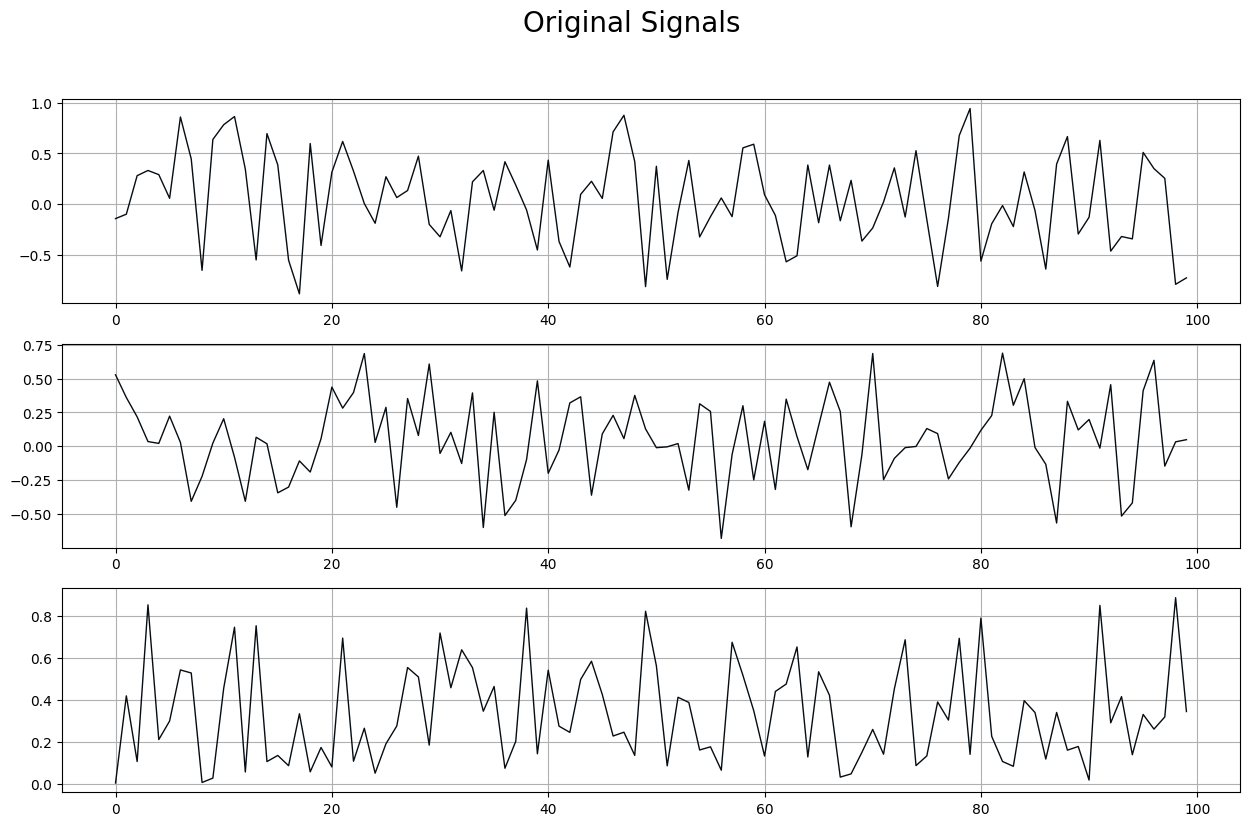

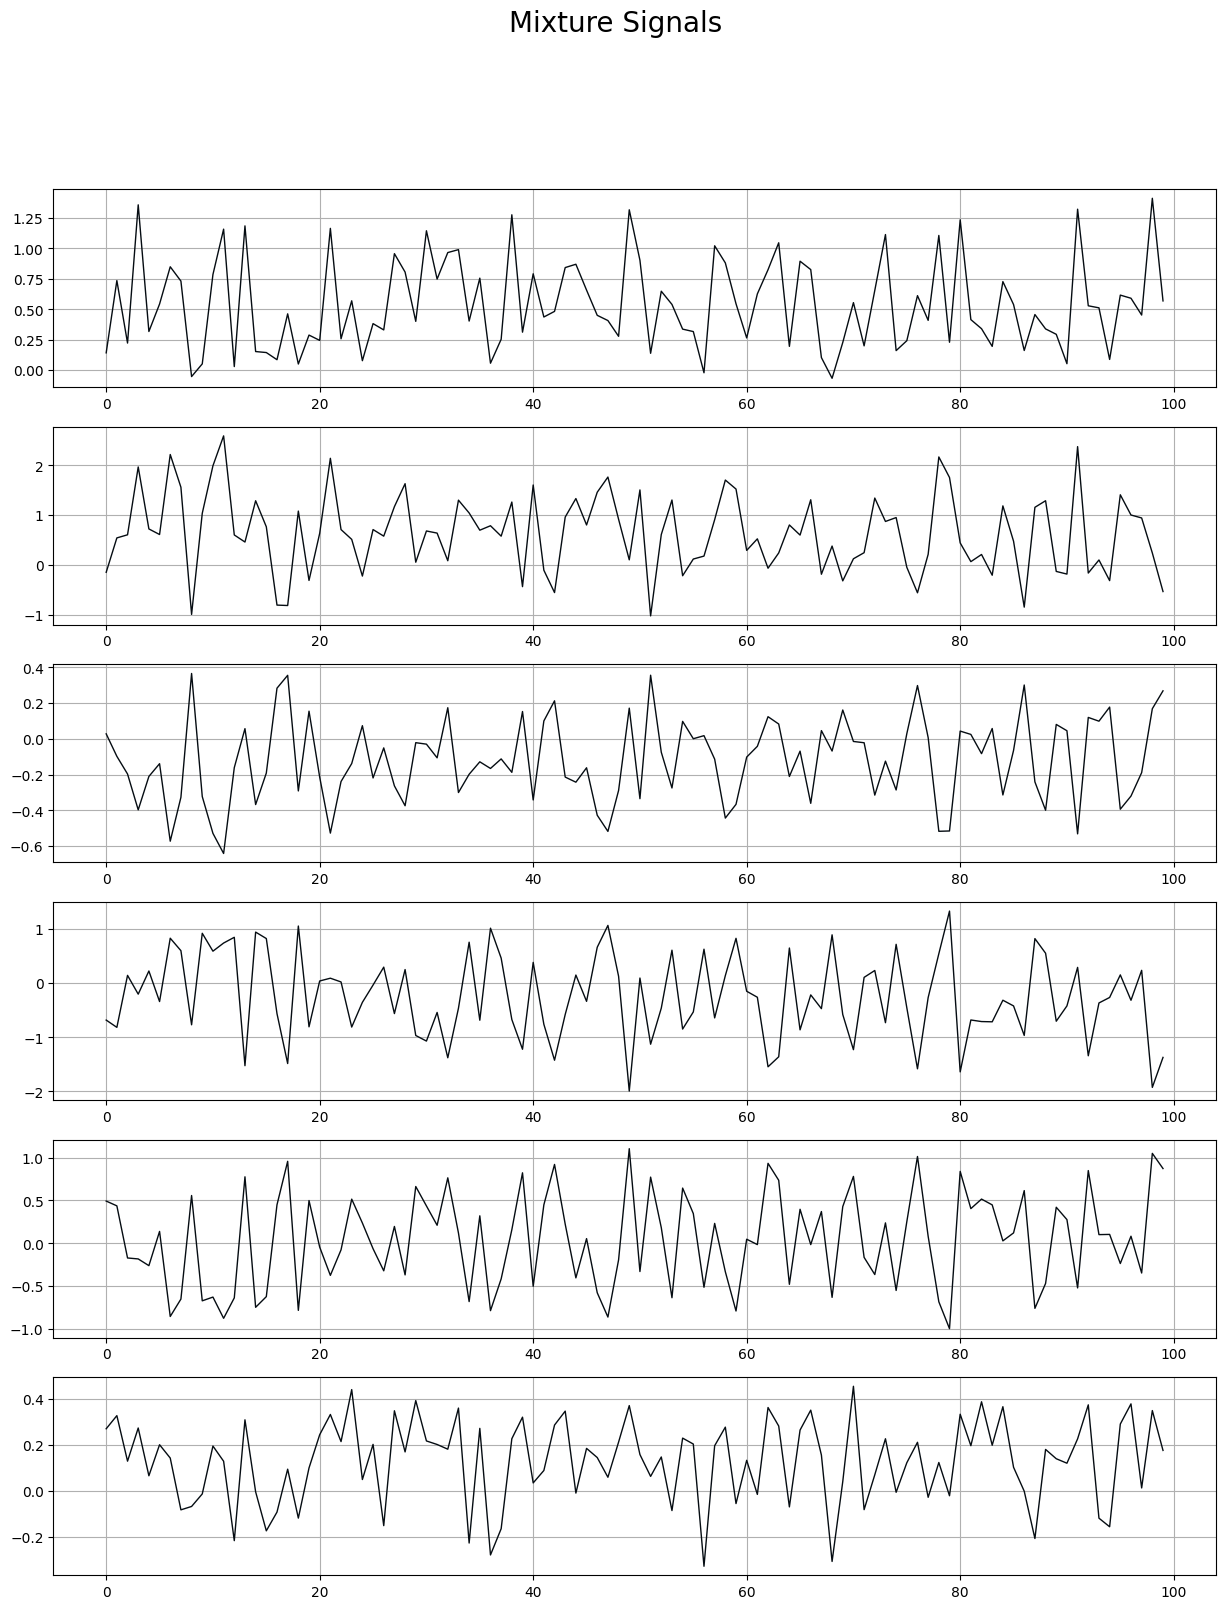

In [6]:
subplot_1D_signals(
    S[:, 0:100], title="Original Signals", figsize=(15.2, 9)
)
subplot_1D_signals(
    X[:, 0:100], title="Mixture Signals", figsize=(15, 18)
)

# Algorithm Hyperparameter Selection and Weight Initialization

In [7]:
s_dim = S.shape[0]
x_dim = X.shape[0]

debug_iteration_point = 50000
model = PredictiveDecorrGeneralPolytope(
    n_sources=s_dim,
    signed_dims=signed_dims,
    nn_dims=nn_dims,
    sparse_dims_list=sparse_dims_list,
    epsilon=1e-3,
    lambda_lateral=0.998,
    gamma_predictive=100,
    lr_W=5 * 1e-2,
    lr_W_rule="divide_by_index",
    lr_W_decay_divider=100000,
    neural_lr_start=0.01,
    neural_lr_stop=1e-5,
    neural_dynamics_iterations=300,
    stlambda_lr=1.5,
    neural_OUTPUT_COMP_TOL=1e-6,
    Sgt=S,
    debug_iteration_point=debug_iteration_point,
    plot_debug_during_training=True,
)

# Run Predictive Entropy Maximization Algorithm on Mixture Signals

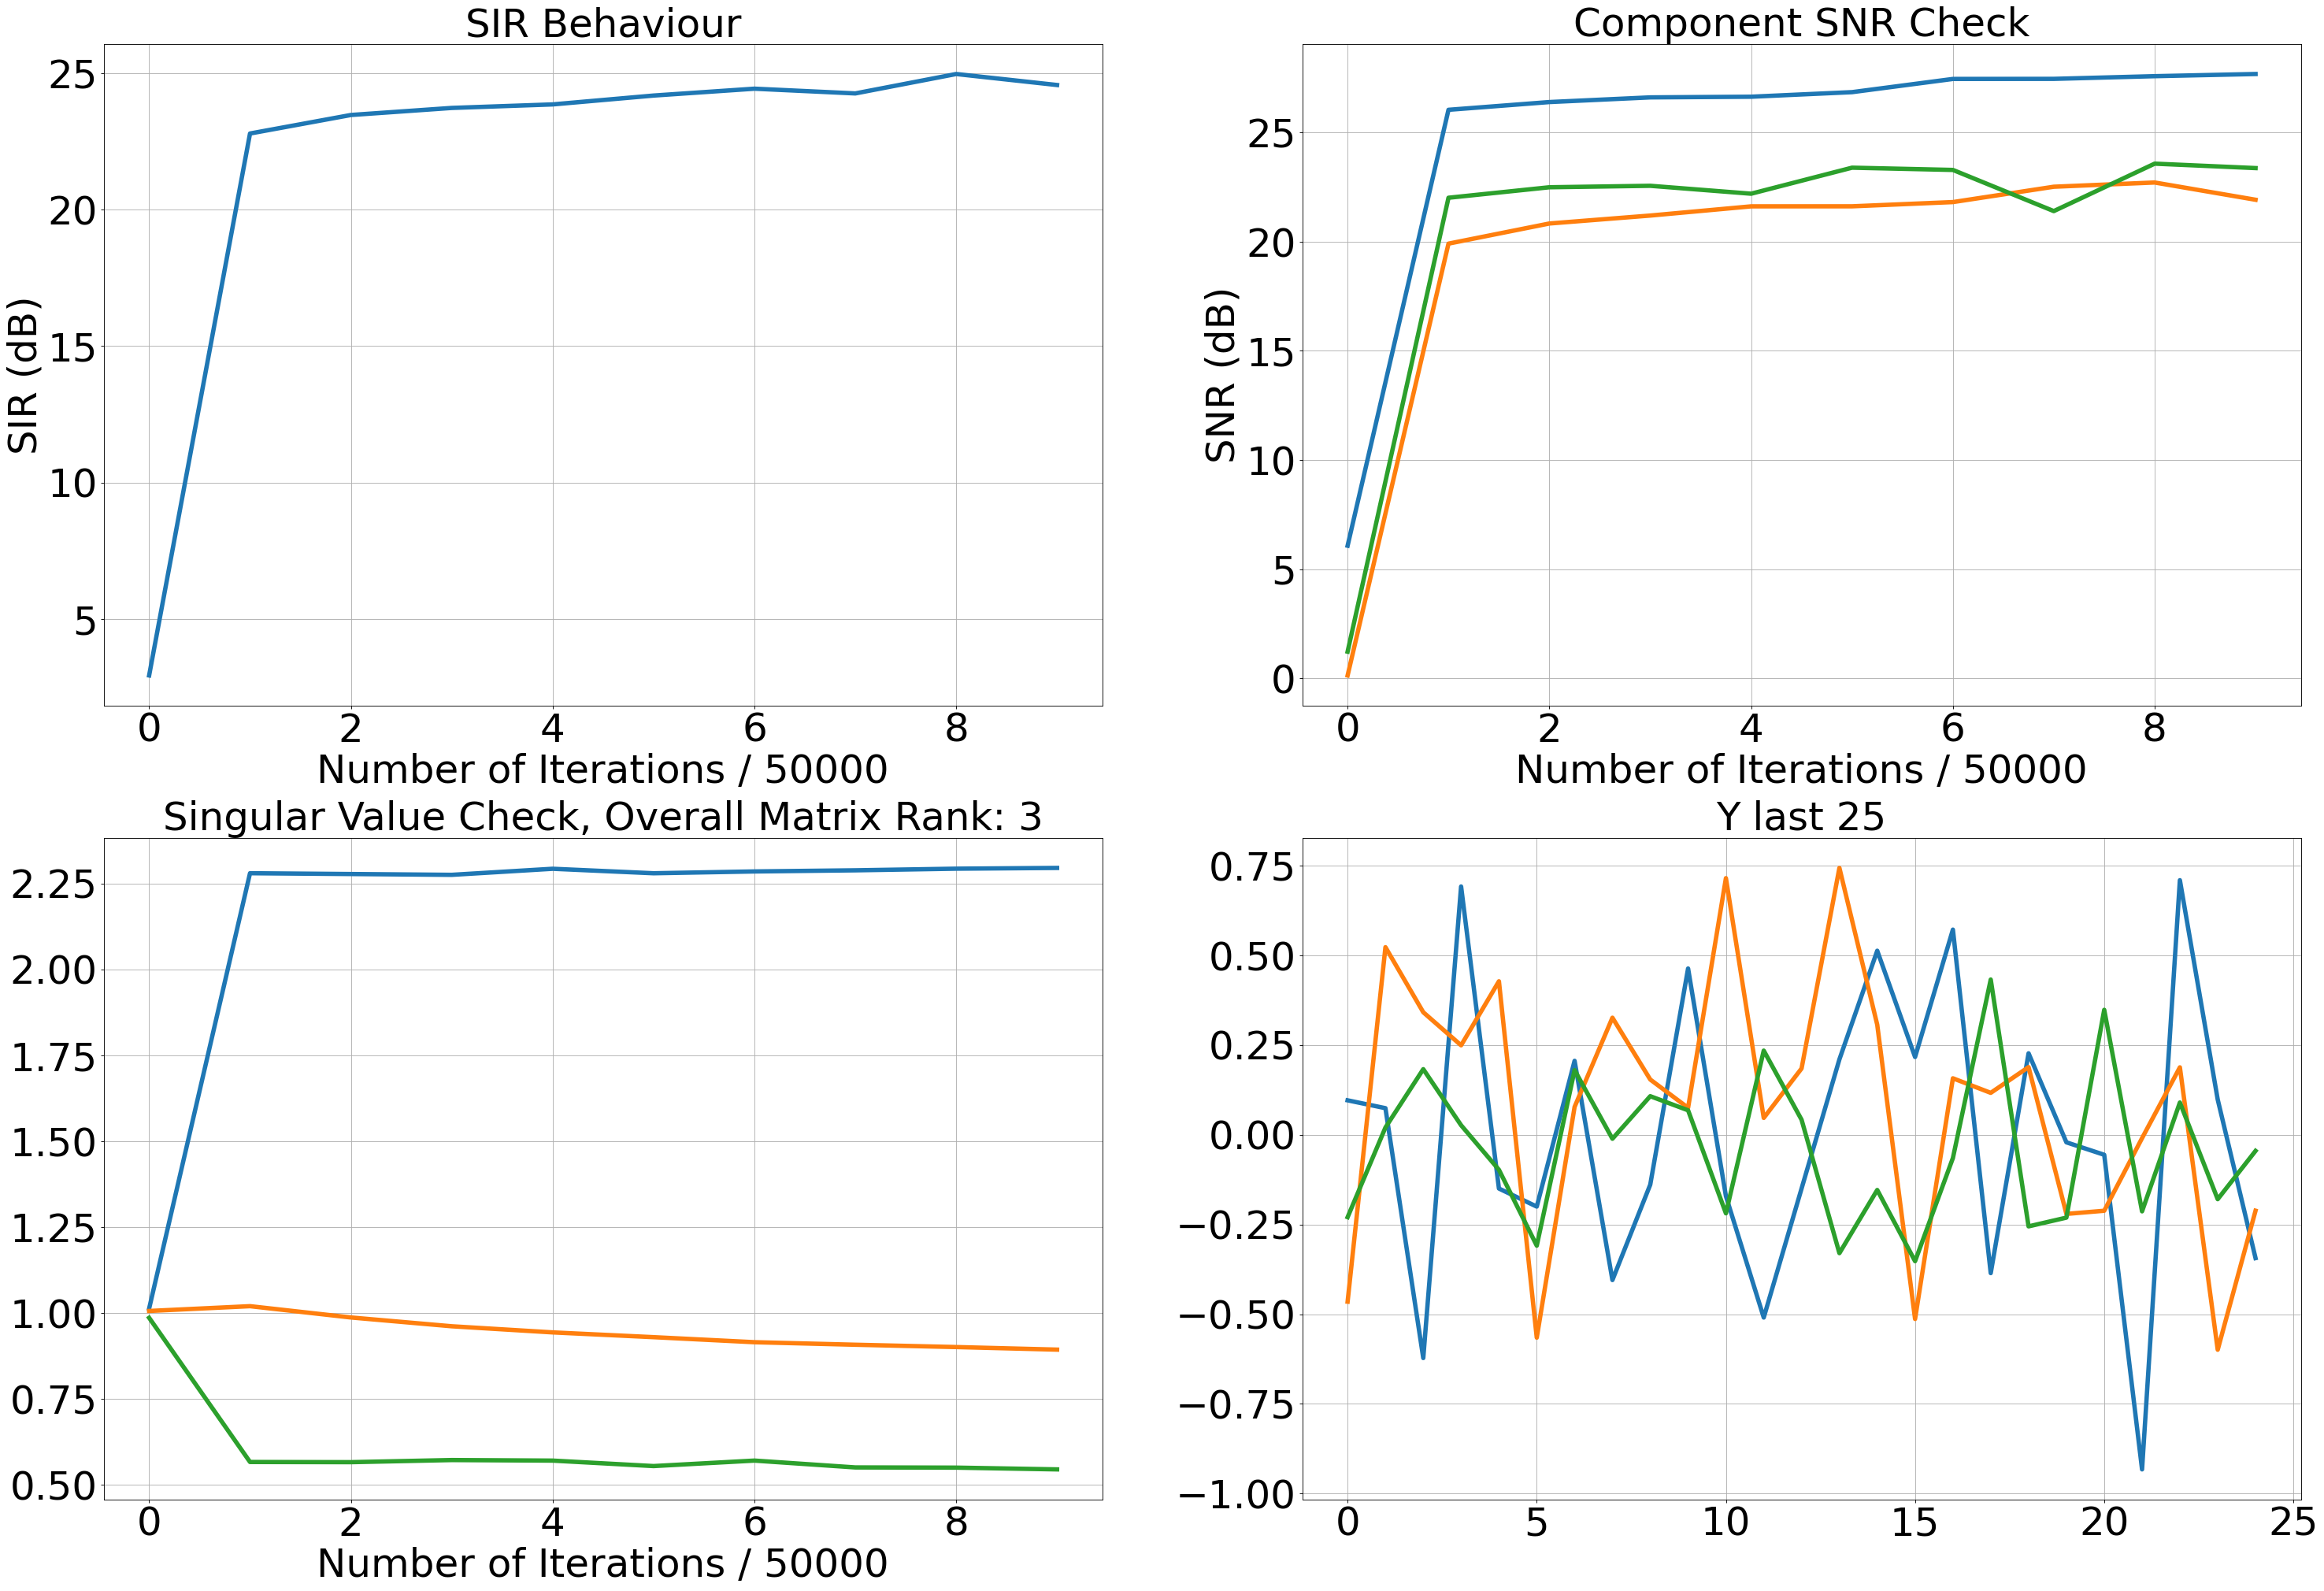

100%|█████████████████████████████████| 500000/500000 [01:09<00:00, 7200.79it/s]


Algorithm took 69.467069 sec.


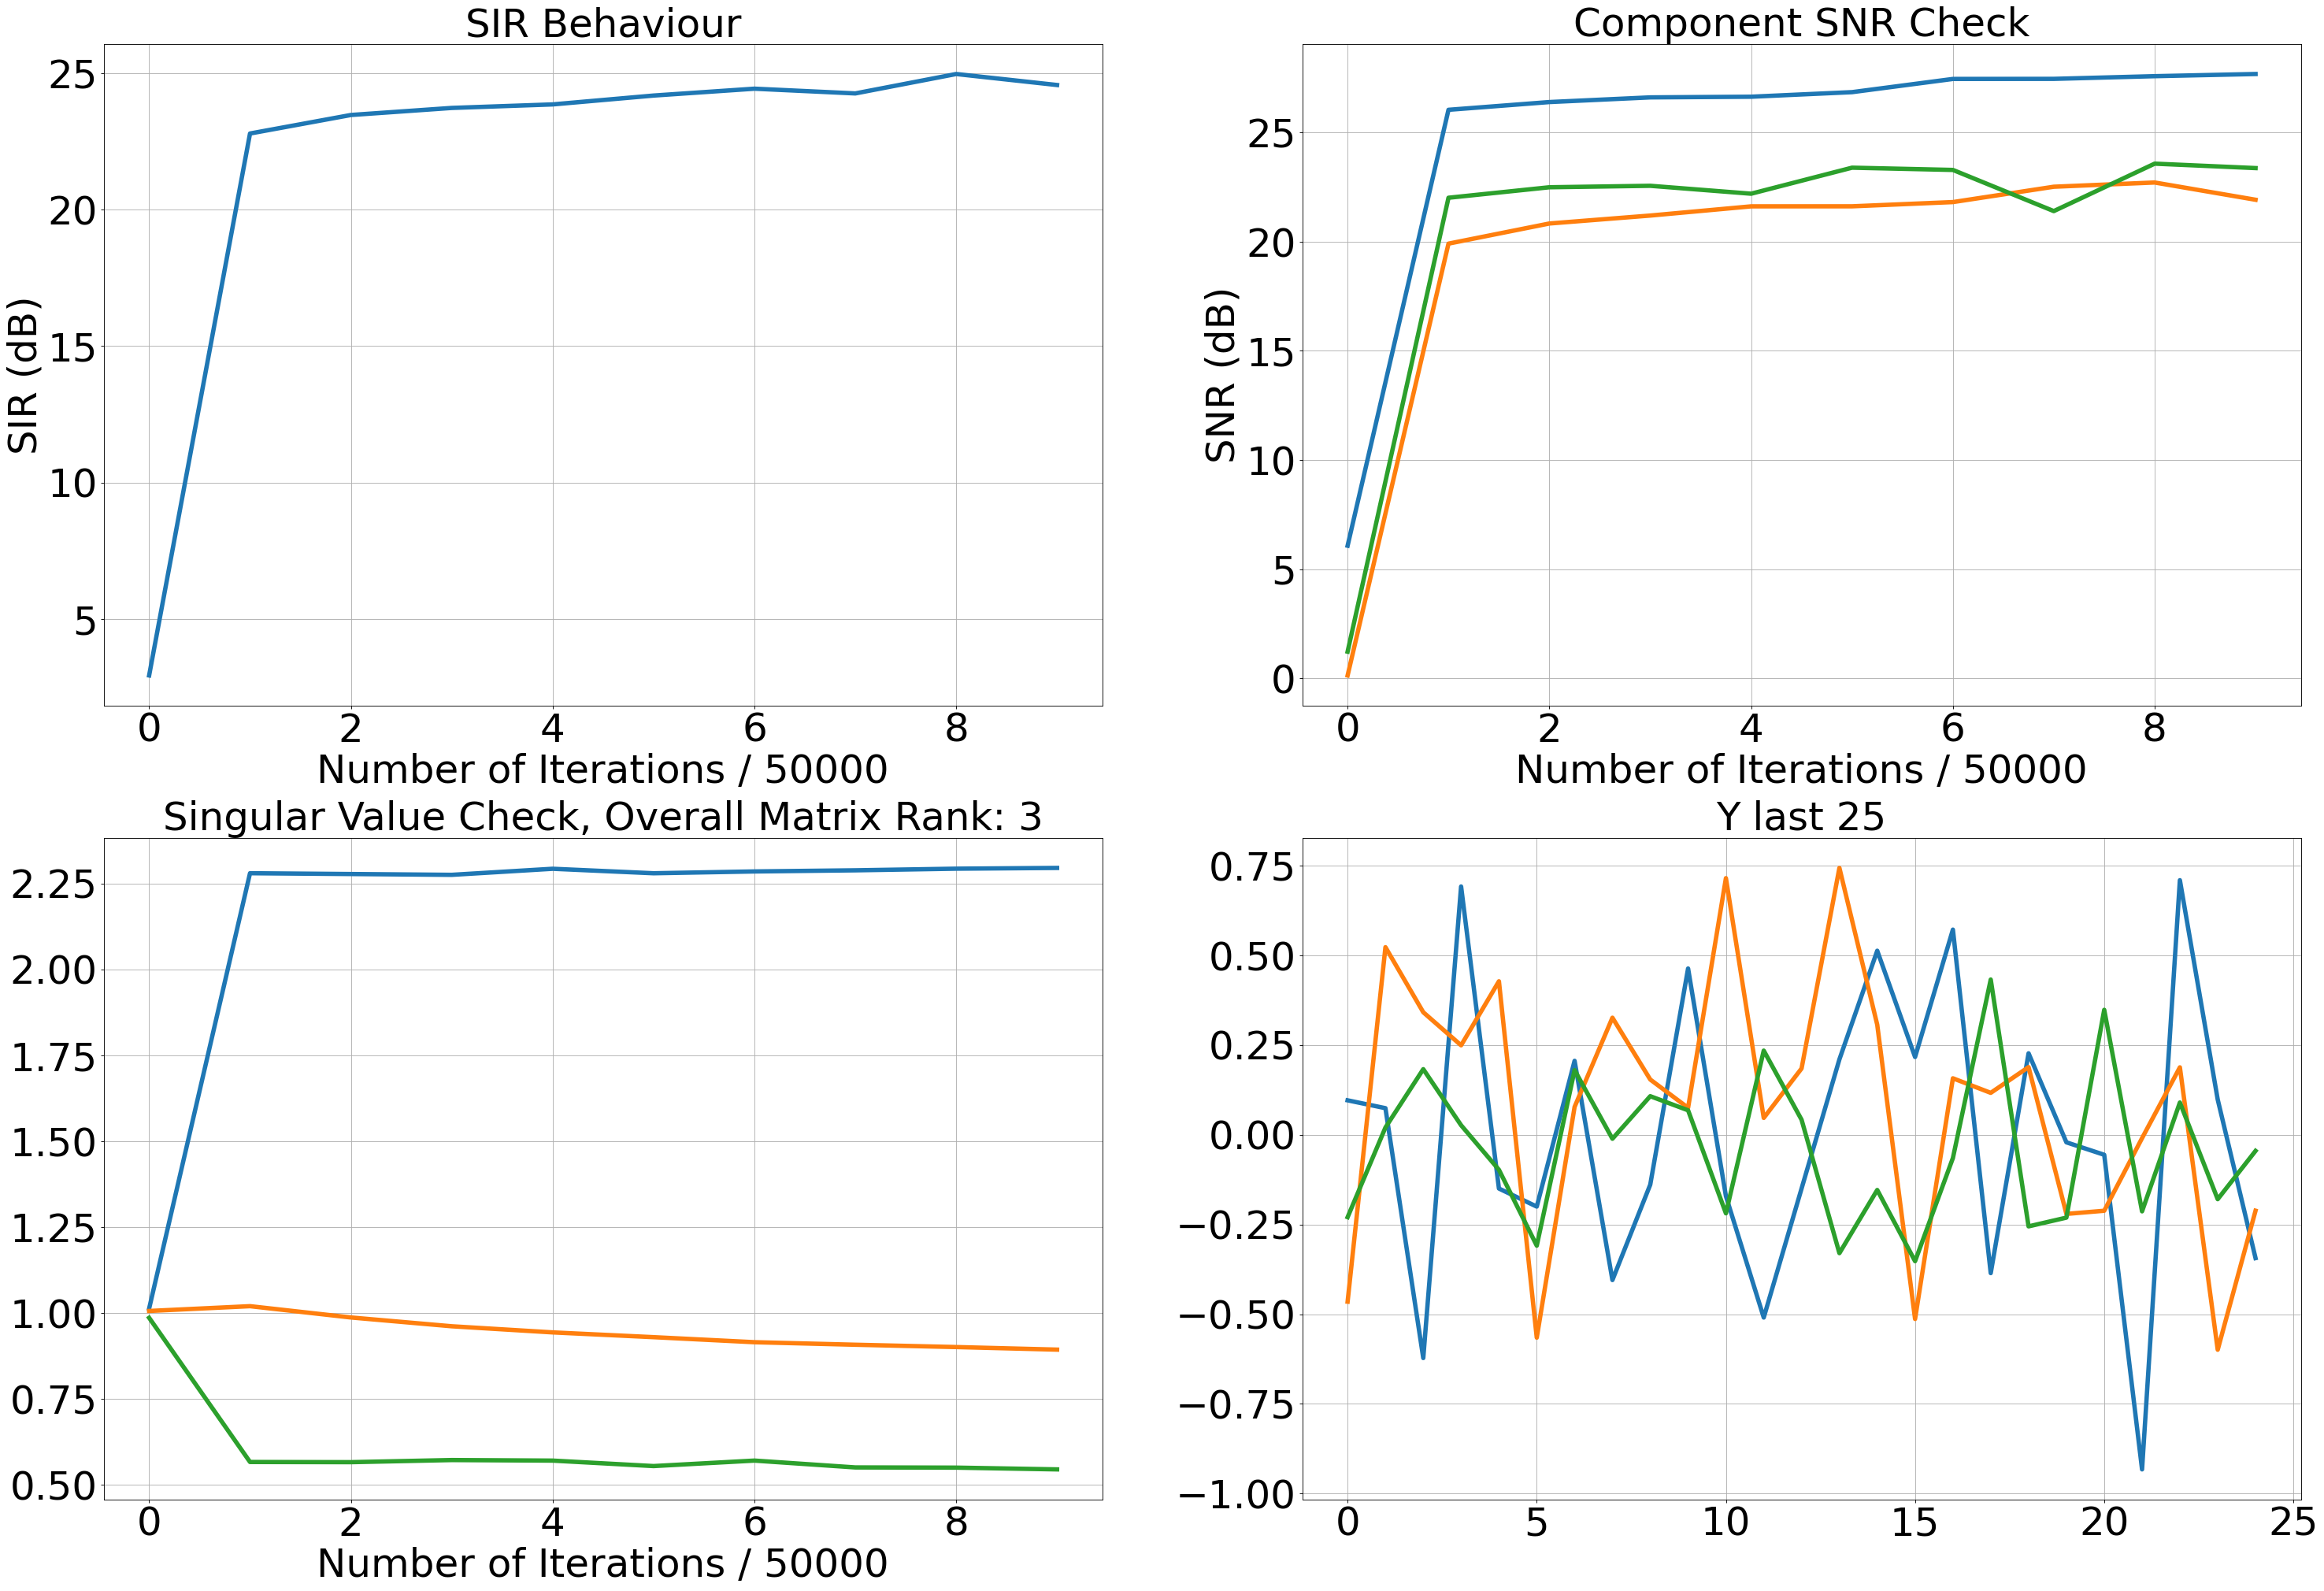

In [8]:
with Timer() as t:
    model.fit(
        X,
        n_epochs=1,
        shuffle_samples=True,
    )
print("Algorithm took %f sec." % (t.interval))

# Visualize SINR Convergence

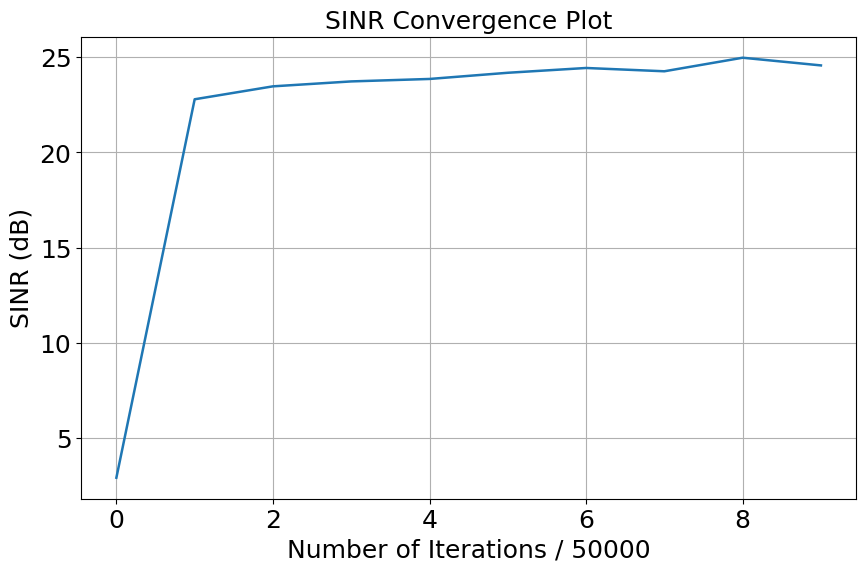

Final SINR: 24.56675909398943


In [9]:
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
plt.figure(figsize=(10, 6))
plt.plot(np.array(model.SINR_history), linewidth=1.8)
plt.xlabel("Number of Iterations / {}".format(debug_iteration_point), fontsize=18)
plt.ylabel("SINR (dB)", fontsize=18)
plt.title("SINR Convergence Plot", fontsize=18)
plt.grid()
plt.show()

print("Final SINR: {}".format(np.array(model.SINR_history[-1])))

# Calculate Resulting Component SNRs and Overall SINR

In [10]:
Szeromean = S - S.mean(axis=1).reshape(-1, 1)
Wf = model.W
Y_ = Wf @ X
Yzeromean = Y_ - Y_.mean(axis=1).reshape(-1, 1)
Y_ = model.signed_and_permutation_corrected_sources(Szeromean, Yzeromean)
coef_ = ((Y_ * Szeromean).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
Y_ = coef_ * Y_

print("Component SNR Values : {}\n".format(model.ComputeSNR(Szeromean, Y_)))

SINR = model.ComputeSINR(Szeromean, Y_)

print("Overall SINR : {}".format(SINR))

Component SNR Values : [27.86448615 22.92182631 23.86627358]

Overall SINR : 25.217186778520094


# Vizualize Extracted Signals Compared to Original Sources

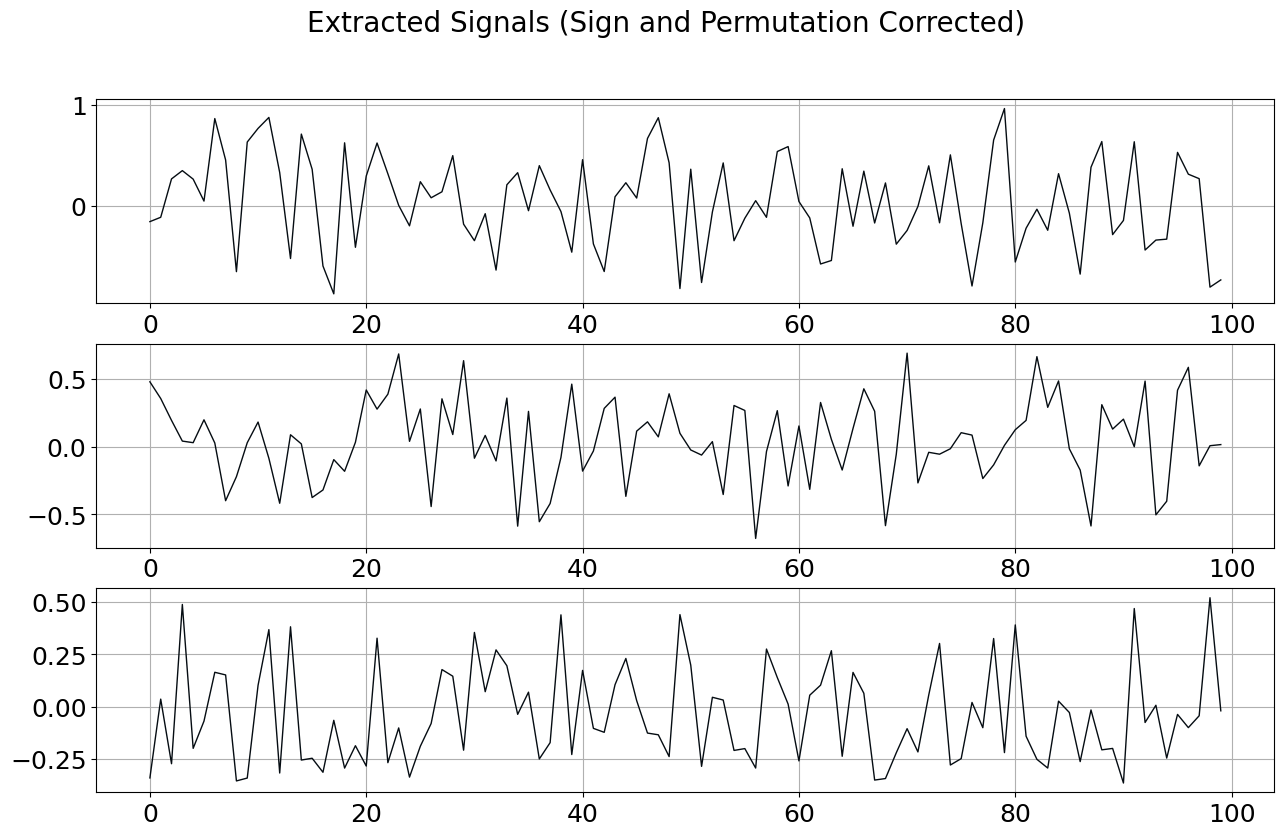

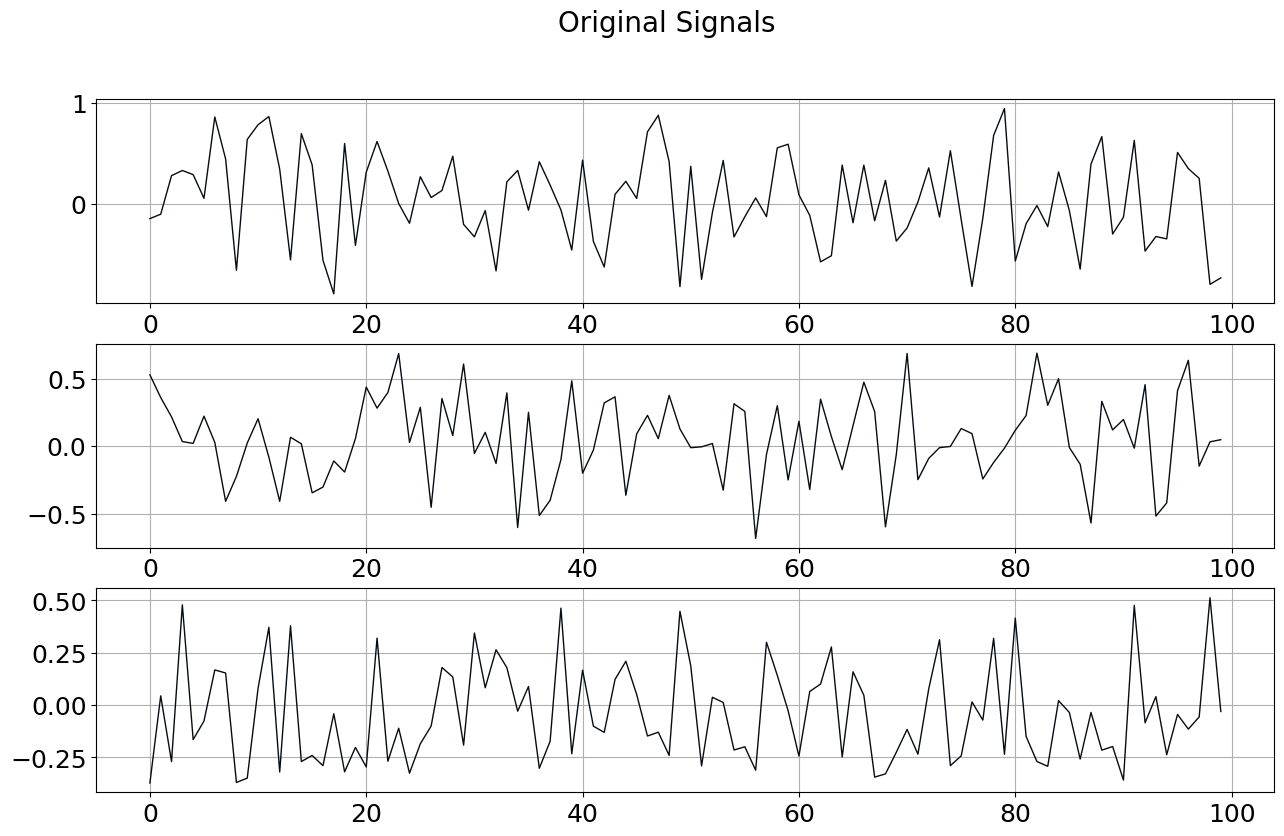

In [11]:
subplot_1D_signals(
    Y_[:, 0:100],
    title="Extracted Signals (Sign and Permutation Corrected)",
    figsize=(15.2, 9),
)
subplot_1D_signals(
    Szeromean[:, 0:100], title="Original Signals", figsize=(15.2, 9)
)